In [1]:
from pathlib import Path
import sys

# Evita extensões opcionais que podem causar conflito em alguns ambientes.
sys.modules['numexpr'] = None
sys.modules['bottleneck'] = None

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 80)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

DATA_DIR = Path('./dados')
EDGES_GEO_PATH = DATA_DIR / 'edges_geo.parquet'

In [3]:
parquet_file = pq.ParquetFile(EDGES_GEO_PATH)
edges_geo = parquet_file.read().to_pandas()
edges_geo.head()

,id_emisor,id_receiver,q_calls,residence_distance_km,calls_duration_total,avg_duration_per_call,emissor_residence_geometry,emissor_residence_city,emissor_residence_quintile_state,emissor_residence_quintile_nation,receptor_residence_geometry,receptor_residence_city,receptor_residence_quintile_state,receptor_residence_quintile_nation
1,E251FECC98A8A1A6A669F4A96E5E83FD,37EDC910464F29BEB60588CE5A3CE0D4,18,5.480985,139.54,7.752222,b'\x01\x01\x00\x00\x00$(~\x8c\xb9\x8bG\xc0\x8b\xcd\xc7\xb5\xa1\xf26\xc0',Campinas,q3,q3,b'\x01\x01\x00\x00\x00\xcb\x7fH\xbf}\x85G\xc0\x85\x99\xb6\x7fe\xed6\xc0',Campinas,q4,q4
2,89DCFE25604A02CB8B80725D4AA896C6,8DBF6A18EEB743B322CB639529E90198,1,0.000000,2.45,2.450000,b'\x01\x01\x00\x00\x00j\xa4\xa5\xf2v\x98G\xc0b\x15od\x1e\xd96\xc0',Campinas,q4,q4,b'\x01\x01\x00\x00\x00j\xa4\xa5\xf2v\x98G\xc0b\x15od\x1e\xd96\xc0',Campinas,q4,q4
3,1DEF0A07C69528F86FC5F9540511BD10,605AF7D72A6CE93EA7BB0BDB21ACE525,32,0.000000,45.98,1.436875,b'\x01\x01\x00\x00\x00&\x199\x0b{\x8aG\xc0\xc8\x02&p\xeb\xe66\xc0',Campinas,q5,q5,b'\x01\x01\x00\x00\x00&\x199\x0b{\x8aG\xc0\xc8\x02&p\xeb\xe66\xc0',Campinas,q5,q5
4,9749A47A3F466E787C1262E04FFDA8A1,9F34A780F9A3F3EA69867ECFCE914735,4,9.379525,1.55,0.387500,b'\x01\x01\x00\x00\x00\x05Q\xf7\x01H\x99G\xc0\xe6?\xa4\xdf\xbe\xe66\xc0',Campinas,q3,q4,b'\x01\x01\x00\x00\x00f\x83L2r\x8eG\xc0\x03\x829z\xfc\xee6\xc0',Campinas,q4,q5
5,D4A62AA301336DBC49DA15BE818665A1,691BAC0D4F95B0D85118C79226F42B99,39,0.000000,33.43,0.857179,b'\x01\x01\x00\x00\x00\xf2A\xcff\xd5\x9fG\xc0\x1c\xf0\xf9a\x84\xe06\xc0',Campinas,q5,q5,b'\x01\x01\x00\x00\x00\xf2A\xcff\xd5\x9fG\xc0\x1c\xf0\xf9a\x84\xe06\xc0',Campinas,q5,q5


In [5]:
edges_geo.shape

(48947, 14)

## Dicionário dos dados usados

| Coluna | Como será usada aqui |
|----------|----------|
| `id_emisor` | Identificador anonimizado do usuário que realizou a chamada. Representa o nó de origem da aresta. |
| `id_receiver` | Identificador anonimizado do usuário que recebeu a chamada. Representa o nó de destino da aresta. |
| `q_calls` | Quantidade total de chamadas realizadas entre o emissor e o receptor. Utilizada como medida de intensidade da conexão. |
| `calls_duration_total` | Soma da duração de todas as chamadas entre o emissor e o receptor. Utilizada como peso alternativo da aresta. |
| `residence_distance_km` | Distância residencial, em quilômetros, entre emissor e receptor. Utilizada para análises espaciais da rede. |
| `emissor_residence_city` | Cidade de residência do emissor. Utilizada para caracterização geográfica e detecção de padrões espaciais. |
| `receptor_residence_city` | Cidade de residência do receptor. Utilizada para caracterização geográfica e análise de fluxos entre cidades. |
| `emissor_residence_quintile_state` | Quintil socioeconômico estadual do emissor. Utilizado para investigar homofilia socioeconômica. |
| `receptor_residence_quintile_state` | Quintil socioeconômico estadual do receptor. Utilizado para investigar homofilia socioeconômica. |
| `emissor_residence_quintile_nation` | Quintil socioeconômico nacional do emissor. Utilizado para análises complementares de estratificação social. |
| `receptor_residence_quintile_nation` | Quintil socioeconômico nacional do receptor. Utilizado para análises complementares de estratificação social. |
| `emissor_residence_geometry` | Coordenadas geográficas da residência do emissor. Utilizadas para cálculos espaciais e visualizações geográficas. |
| `receptor_residence_geometry` | Coordenadas geográficas da residência do receptor. Utilizadas para cálculos espaciais e visualizações geográficas. |

### Interpretação da tabela

Cada linha representa uma **aresta da rede de comunicação**, contendo:

- quem realizou a ligação;
- quem recebeu a ligação;
- a intensidade da interação (`q_calls`);
- a duração acumulada da comunicação (`calls_duration_total`);
- a distância geográfica entre os usuários (`residence_distance_km`);
- atributos espaciais e socioeconômicos dos dois extremos da aresta.

Essa estrutura permite construir grafos ponderados e realizar análises de:

- distribuição de grau;
- centralidade;
- comunidades;
- small-world;
- homofilia socioeconômica;
- dependência espacial das comunicações.

# Construção da Rede

In [2]:
import networkx as nx

## Grafo básico

In [11]:
import networkx as nx

G = nx.from_pandas_edgelist(
    edges_geo,
    source="id_emisor",
    target="id_receiver"
)

print(f"Nós: {G.number_of_nodes():.0f}")
print(f"Arestas: {G.number_of_edges():.0f}")

Nós: 25176
Arestas: 31509


In [12]:
print(nx.density(G))

9.94279320258666e-05


Uma densidade muito baixa indica que:

a rede é esparsa;

as pessoas mantêm poucos contatos em relação ao total da população;

provavelmente existem comunidades locais;

faz sentido procurar hubs e estruturas sociais.

## Distribuição de grau

### Histograma de graus

In [13]:
graus = [d for _, d in G.degree()]

Text(0, 0.5, 'Frequência')

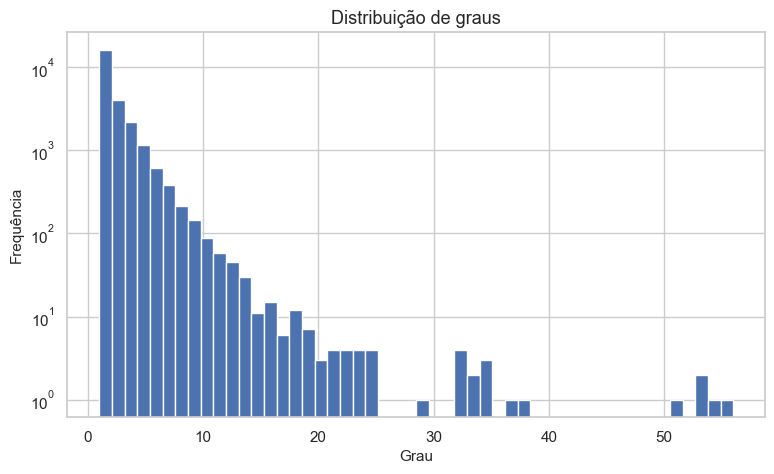

In [17]:
plt.hist(graus, bins=50, log=True);
plt.title("Distribuição de graus")
plt.xlabel("Grau")
plt.ylabel("Frequência")

In [15]:
pd.Series(graus).describe()

count    25176.000000
mean         2.503098
std          2.224052
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         56.000000
dtype: float64

A distribuição de grau da rede revela uma forte concentração de usuários com poucas conexões. Observa-se que 25% dos nós possuem apenas uma conexão, enquanto a mediana é igual a 2, indicando que metade dos usuários se comunica com no máximo duas pessoas distintas. Além disso, 75% dos nós apresentam grau inferior ou igual a 3.

Apesar dessa concentração em baixos valores de grau, existem usuários significativamente mais conectados, alcançando grau máximo de 56. A diferença entre a mediana (2) e o grau máximo (56) sugere a presença de uma cauda longa na distribuição, característica frequentemente observada em redes sociais e de comunicação.

Esse comportamento indica uma rede heterogênea, composta majoritariamente por usuários com poucas conexões e por um pequeno conjunto de nós altamente conectados, que podem atuar como hubs na estrutura da rede.


## CCDF

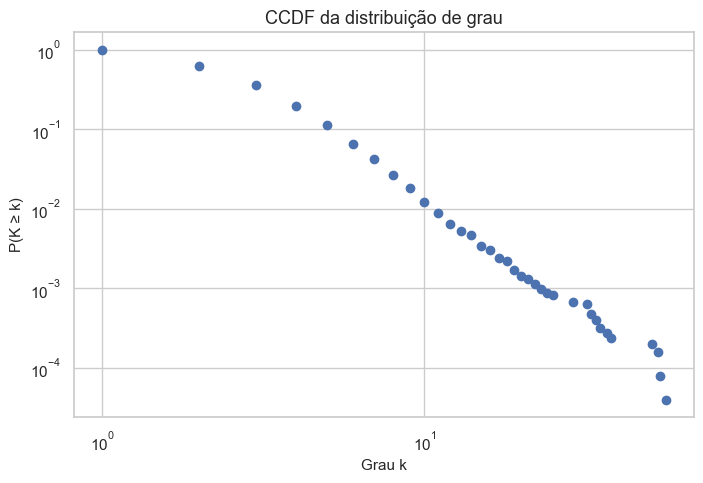

In [18]:
graus = np.array(graus)

x = np.sort(np.unique(graus))
ccdf = [np.mean(graus >= k) for k in x]

plt.figure(figsize=(8,5))
plt.loglog(x, ccdf, marker='o', linestyle='')

plt.xlabel("Grau k")
plt.ylabel("P(K ≥ k)")
plt.title("CCDF da distribuição de grau")
plt.grid(True)
plt.show()

A função de distribuição acumulada complementar (CCDF, *Complementary Cumulative Distribution Function*) representa a probabilidade de um nó possuir grau maior ou igual a um determinado valor (k). Em outras palavras, para cada valor de grau, a CCDF informa qual fração da rede possui pelo menos aquela quantidade de conexões.

De forma intuitiva, a CCDF pode ser interpretada como a parcela dos usuários que permanece "acima" de um determinado grau. Por exemplo, se para (k=10) a CCDF vale 0,01, isso significa que aproximadamente 1% dos usuários possuem 10 ou mais conexões. Assim, enquanto um histograma mostra quantos nós existem em cada grau, a CCDF mostra a proporção acumulada de nós que possuem grau igual ou superior a cada valor considerado.

A principal vantagem da CCDF é evidenciar o comportamento da cauda da distribuição, permitindo identificar a presença de nós altamente conectados (hubs) que podem ficar ocultos em histogramas convencionais.

Observa-se que a probabilidade decresce gradualmente à medida que o grau aumenta, indicando que a maior parte dos usuários possui poucas conexões, enquanto uma pequena parcela apresenta número significativamente maior de contatos. Esse comportamento evidencia a existência de uma cauda longa na distribuição de grau.

Além disso, a curva apresenta um trecho aproximadamente linear em escala log-log, característica frequentemente associada a distribuições de cauda pesada encontradas em redes sociais e de comunicação. Esses resultados sugerem que a rede é estruturalmente heterogênea, composta por muitos usuários pouco conectados e por um conjunto reduzido de nós que atuam como hubs na rede.


## Componentes conexas

In [19]:
components = list(nx.connected_components(G))

In [20]:
len(components)

2549

In [21]:
largest_cc = max(components, key=len)

len(largest_cc)

18043

Uma componente conexa corresponde a um conjunto de nós em que existe pelo menos um caminho ligando qualquer par de usuários pertencentes ao mesmo grupo. Em outras palavras, todos os indivíduos de uma mesma componente podem ser alcançados por meio de conexões diretas ou indiretas.

A rede analisada apresentou 2549 componentes conexas distintas, indicando a existência de diversos grupos independentes de usuários. Entretanto, observou-se a presença de uma componente gigante contendo 18043 nós, o que representa aproximadamente 72% de todos os usuários da rede.

Esse resultado sugere que a maior parte dos indivíduos pertence a uma única estrutura conectada, permitindo que informações, influências ou interações se propaguem através de caminhos indiretos entre a maioria dos usuários. As demais componentes são significativamente menores e representam grupos isolados ou fracamente conectados ao restante da rede.

A coexistência de uma componente gigante com diversas componentes pequenas é um comportamento frequentemente observado em redes reais de comunicação e interação social, indicando uma estrutura globalmente conectada, mas com a presença de grupos periféricos que permanecem desconectados da maior parte da população.


## Clustering

In [22]:
nx.average_clustering(G)

0.16234449904592357

O coeficiente de clustering mede a tendência de formação de grupos locais na rede. De forma intuitiva, essa métrica avalia a probabilidade de que dois vizinhos de um mesmo usuário também estejam conectados entre si, formando estruturas triangulares.

A rede apresentou coeficiente de clustering médio igual a 0,16. Isso indica que aproximadamente 16% das conexões potenciais entre vizinhos efetivamente ocorrem na rede.

Embora esse valor esteja distante do máximo possível (1,0), ele é significativamente superior ao esperado para redes puramente aleatórias, sugerindo a presença de agrupamentos locais de usuários. Esse comportamento é compatível com redes reais de comunicação, nas quais indivíduos pertencentes a círculos sociais semelhantes — como familiares, amigos, colegas de trabalho ou vizinhos — tendem a estabelecer conexões entre si.

A presença de clustering não nulo reforça a hipótese de que a rede apresenta organização social subjacente, com formação de grupos locais e padrões de interação que não podem ser explicados apenas pelo acaso.


## Comunidades

In [23]:
largest_cc = max(nx.connected_components(G), key=len)

Gcc = G.subgraph(largest_cc).copy()

In [25]:
from networkx.algorithms.community import (
    greedy_modularity_communities
)

communities = list(
    greedy_modularity_communities(Gcc)
)

In [26]:
len(communities)

112

In [27]:
sizes = sorted(
    [len(c) for c in communities],
    reverse=True
)

sizes[:20]

[480,
 449,
 406,
 305,
 282,
 275,
 267,
 259,
 258,
 254,
 250,
 247,
 239,
 239,
 233,
 232,
 230,
 226,
 225,
 217]

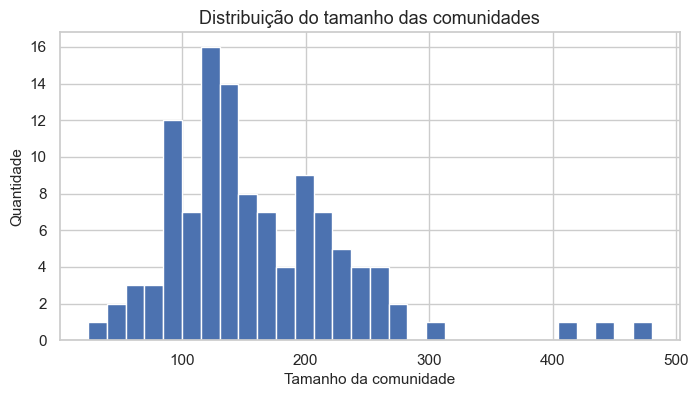

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(sizes, bins=30)

plt.xlabel("Tamanho da comunidade")
plt.ylabel("Quantidade")
plt.title("Distribuição do tamanho das comunidades")

plt.show()

In [29]:
pd.Series(sizes).describe()

count    112.000000
mean     161.098214
std       74.875507
min       24.000000
25%      116.500000
50%      141.500000
75%      204.500000
max      480.000000
dtype: float64

A detecção de comunidades foi realizada sobre a componente gigante da rede utilizando um algoritmo baseado em maximização de modularidade. Foram identificadas 112 comunidades distintas, evidenciando uma estrutura fortemente modular.

A análise da distribuição dos tamanhos das comunidades mostrou que a maior parte dos grupos possui entre aproximadamente 100 e 220 usuários. A mediana observada foi de 141,5 nós, enquanto 75% das comunidades possuem até 204,5 nós. A maior comunidade identificada contém 480 usuários, representando apenas uma pequena fração da componente gigante da rede.

O histograma dos tamanhos das comunidades indica uma distribuição relativamente concentrada, sem a presença de uma comunidade dominante que reúna parcela significativa dos usuários. Em vez disso, observa-se a formação de diversos grupos de tamanho semelhante, sugerindo uma organização social distribuída em múltiplos núcleos de interação.

Esse comportamento é compatível com redes reais de comunicação, nas quais os indivíduos tendem a se organizar em grupos sociais locais, como famílias, círculos de amizade, ambientes de trabalho ou comunidades geograficamente próximas. A ausência de comunidades excessivamente grandes sugere que a rede apresenta uma estrutura modular equilibrada, composta por diversos grupos relativamente independentes entre si.

Esses resultados indicam que a organização interna da rede não é aleatória, apresentando agrupamentos bem definidos que poderão ser posteriormente comparados com informações geográficas e socioeconômicas para investigar a relação entre comunidade, localização e perfil dos usuários.


# Estrutura Geográfica da Rede

In [32]:
from shapely import wkb
import ast

5. Estrutura Geográfica da Rede

5.1 Distribuição espacial dos usuários

5.2 Distância geográfica das conexões

5.3 Comunidades e localização geográfica

5.4 Intensidade da comunicação versus distância

5.5 Visualização da rede sobre o mapa de Campinas

## Extrair coordenadas

Vamos tentar decifrar essas coordenadas

In [30]:
edges_geo["emissor_residence_geometry"].iloc[0]

"b'\\x01\\x01\\x00\\x00\\x00$(~\\x8c\\xb9\\x8bG\\xc0\\x8b\\xcd\\xc7\\xb5\\xa1\\xf26\\xc0'"

In [31]:
edges_geo["emissor_residence_geometry"].head()

1    b'\x01\x01\x00\x00\x00$(~\x8c\xb9\x8bG\xc0\x8b\xcd\xc7\xb5\xa1\xf26\xc0'
2          b'\x01\x01\x00\x00\x00j\xa4\xa5\xf2v\x98G\xc0b\x15od\x1e\xd96\xc0'
3          b'\x01\x01\x00\x00\x00&\x199\x0b{\x8aG\xc0\xc8\x02&p\xeb\xe66\xc0'
4    b'\x01\x01\x00\x00\x00\x05Q\xf7\x01H\x99G\xc0\xe6?\xa4\xdf\xbe\xe66\xc0'
5    b'\x01\x01\x00\x00\x00\xf2A\xcff\xd5\x9fG\xc0\x1c\xf0\xf9a\x84\xe06\xc0'
Name: emissor_residence_geometry, dtype: str

In [34]:
s = edges_geo["emissor_residence_geometry"].iloc[0]

geom = wkb.loads(
    ast.literal_eval(s)
)

print(geom)
print(geom.x, geom.y)

POINT (-47.0916 -22.947780000000005)
-47.0916 -22.947780000000005


In [35]:
edges_geo["emissor_geom"] = (
    edges_geo["emissor_residence_geometry"]
    .apply(lambda x: wkb.loads(ast.literal_eval(x)))
)

edges_geo["receptor_geom"] = (
    edges_geo["receptor_residence_geometry"]
    .apply(lambda x: wkb.loads(ast.literal_eval(x)))
)

In [36]:
edges_geo.head()

,id_emisor,id_receiver,q_calls,residence_distance_km,calls_duration_total,avg_duration_per_call,emissor_residence_geometry,emissor_residence_city,emissor_residence_quintile_state,emissor_residence_quintile_nation,receptor_residence_geometry,receptor_residence_city,receptor_residence_quintile_state,receptor_residence_quintile_nation,emissor_geom,receptor_geom
1,E251FECC98A8A1A6A669F4A96E5E83FD,37EDC910464F29BEB60588CE5A3CE0D4,18,5.480985,139.54,7.752222,b'\x01\x01\x00\x00\x00$(~\x8c\xb9\x8bG\xc0\x8b\xcd\xc7\xb5\xa1\xf26\xc0',Campinas,q3,q3,b'\x01\x01\x00\x00\x00\xcb\x7fH\xbf}\x85G\xc0\x85\x99\xb6\x7fe\xed6\xc0',Campinas,q4,q4,POINT (-47.0916 -22.947780000000005),POINT (-47.042899999999996 -22.92733)
2,89DCFE25604A02CB8B80725D4AA896C6,8DBF6A18EEB743B322CB639529E90198,1,0.000000,2.45,2.450000,b'\x01\x01\x00\x00\x00j\xa4\xa5\xf2v\x98G\xc0b\x15od\x1e\xd96\xc0',Campinas,q4,q4,b'\x01\x01\x00\x00\x00j\xa4\xa5\xf2v\x98G\xc0b\x15od\x1e\xd96\xc0',Campinas,q4,q4,POINT (-47.19113 -22.84812),POINT (-47.19113 -22.84812)
3,1DEF0A07C69528F86FC5F9540511BD10,605AF7D72A6CE93EA7BB0BDB21ACE525,32,0.000000,45.98,1.436875,b'\x01\x01\x00\x00\x00&\x199\x0b{\x8aG\xc0\xc8\x02&p\xeb\xe66\xc0',Campinas,q5,q5,b'\x01\x01\x00\x00\x00&\x199\x0b{\x8aG\xc0\xc8\x02&p\xeb\xe66\xc0',Campinas,q5,q5,POINT (-47.08188 -22.902029999999996),POINT (-47.08188 -22.902029999999996)
4,9749A47A3F466E787C1262E04FFDA8A1,9F34A780F9A3F3EA69867ECFCE914735,4,9.379525,1.55,0.387500,b'\x01\x01\x00\x00\x00\x05Q\xf7\x01H\x99G\xc0\xe6?\xa4\xdf\xbe\xe66\xc0',Campinas,q3,q4,b'\x01\x01\x00\x00\x00f\x83L2r\x8eG\xc0\x03\x829z\xfc\xee6\xc0',Campinas,q4,q5,POINT (-47.19751 -22.90135),POINT (-47.11286 -22.933540000000004)
5,D4A62AA301336DBC49DA15BE818665A1,691BAC0D4F95B0D85118C79226F42B99,39,0.000000,33.43,0.857179,b'\x01\x01\x00\x00\x00\xf2A\xcff\xd5\x9fG\xc0\x1c\xf0\xf9a\x84\xe06\xc0',Campinas,q5,q5,b'\x01\x01\x00\x00\x00\xf2A\xcff\xd5\x9fG\xc0\x1c\xf0\xf9a\x84\xe06\xc0',Campinas,q5,q5,POINT (-47.2487 -22.87702),POINT (-47.2487 -22.87702)


In [38]:
edges_geo["emissor_lon"] = edges_geo["emissor_geom"].apply(lambda p: p.x)
edges_geo["emissor_lat"] = edges_geo["emissor_geom"].apply(lambda p: p.y)

edges_geo["receptor_lon"] = edges_geo["receptor_geom"].apply(lambda p: p.x)
edges_geo["receptor_lat"] = edges_geo["receptor_geom"].apply(lambda p: p.y)

In [ ]:
edges_geo["emissor_geom"] = (
    edges_geo["emissor_residence_geometry"]
    .apply(lambda x: wkb.loads(ast.literal_eval(x)))
)

edges_geo["emissor_lon"] = (
    edges_geo["emissor_geom"]
    .apply(lambda p: p.x)
)

edges_geo["emissor_lat"] = (
    edges_geo["emissor_geom"]
    .apply(lambda p: p.y)
)

In [40]:
edges_geo.head()

,id_emisor,id_receiver,q_calls,residence_distance_km,calls_duration_total,avg_duration_per_call,emissor_residence_geometry,emissor_residence_city,emissor_residence_quintile_state,emissor_residence_quintile_nation,receptor_residence_geometry,receptor_residence_city,receptor_residence_quintile_state,receptor_residence_quintile_nation,emissor_geom,receptor_geom,emissor_lon,emissor_lat,receptor_lon,receptor_lat
1,E251FECC98A8A1A6A669F4A96E5E83FD,37EDC910464F29BEB60588CE5A3CE0D4,18,5.480985,139.54,7.752222,b'\x01\x01\x00\x00\x00$(~\x8c\xb9\x8bG\xc0\x8b\xcd\xc7\xb5\xa1\xf26\xc0',Campinas,q3,q3,b'\x01\x01\x00\x00\x00\xcb\x7fH\xbf}\x85G\xc0\x85\x99\xb6\x7fe\xed6\xc0',Campinas,q4,q4,POINT (-47.0916 -22.947780000000005),POINT (-47.042899999999996 -22.92733),-47.09160,-22.94778,-47.04290,-22.92733
2,89DCFE25604A02CB8B80725D4AA896C6,8DBF6A18EEB743B322CB639529E90198,1,0.000000,2.45,2.450000,b'\x01\x01\x00\x00\x00j\xa4\xa5\xf2v\x98G\xc0b\x15od\x1e\xd96\xc0',Campinas,q4,q4,b'\x01\x01\x00\x00\x00j\xa4\xa5\xf2v\x98G\xc0b\x15od\x1e\xd96\xc0',Campinas,q4,q4,POINT (-47.19113 -22.84812),POINT (-47.19113 -22.84812),-47.19113,-22.84812,-47.19113,-22.84812
3,1DEF0A07C69528F86FC5F9540511BD10,605AF7D72A6CE93EA7BB0BDB21ACE525,32,0.000000,45.98,1.436875,b'\x01\x01\x00\x00\x00&\x199\x0b{\x8aG\xc0\xc8\x02&p\xeb\xe66\xc0',Campinas,q5,q5,b'\x01\x01\x00\x00\x00&\x199\x0b{\x8aG\xc0\xc8\x02&p\xeb\xe66\xc0',Campinas,q5,q5,POINT (-47.08188 -22.902029999999996),POINT (-47.08188 -22.902029999999996),-47.08188,-22.90203,-47.08188,-22.90203
4,9749A47A3F466E787C1262E04FFDA8A1,9F34A780F9A3F3EA69867ECFCE914735,4,9.379525,1.55,0.387500,b'\x01\x01\x00\x00\x00\x05Q\xf7\x01H\x99G\xc0\xe6?\xa4\xdf\xbe\xe66\xc0',Campinas,q3,q4,b'\x01\x01\x00\x00\x00f\x83L2r\x8eG\xc0\x03\x829z\xfc\xee6\xc0',Campinas,q4,q5,POINT (-47.19751 -22.90135),POINT (-47.11286 -22.933540000000004),-47.19751,-22.90135,-47.11286,-22.93354
5,D4A62AA301336DBC49DA15BE818665A1,691BAC0D4F95B0D85118C79226F42B99,39,0.000000,33.43,0.857179,b'\x01\x01\x00\x00\x00\xf2A\xcff\xd5\x9fG\xc0\x1c\xf0\xf9a\x84\xe06\xc0',Campinas,q5,q5,b'\x01\x01\x00\x00\x00\xf2A\xcff\xd5\x9fG\xc0\x1c\xf0\xf9a\x84\xe06\xc0',Campinas,q5,q5,POINT (-47.2487 -22.87702),POINT (-47.2487 -22.87702),-47.24870,-22.87702,-47.24870,-22.87702


## Remover duplicatas

In [41]:
users = (
    edges_geo[
        ["id_emisor", "emissor_lon", "emissor_lat"]
    ]
    .drop_duplicates("id_emisor")
)

## Scatter simples

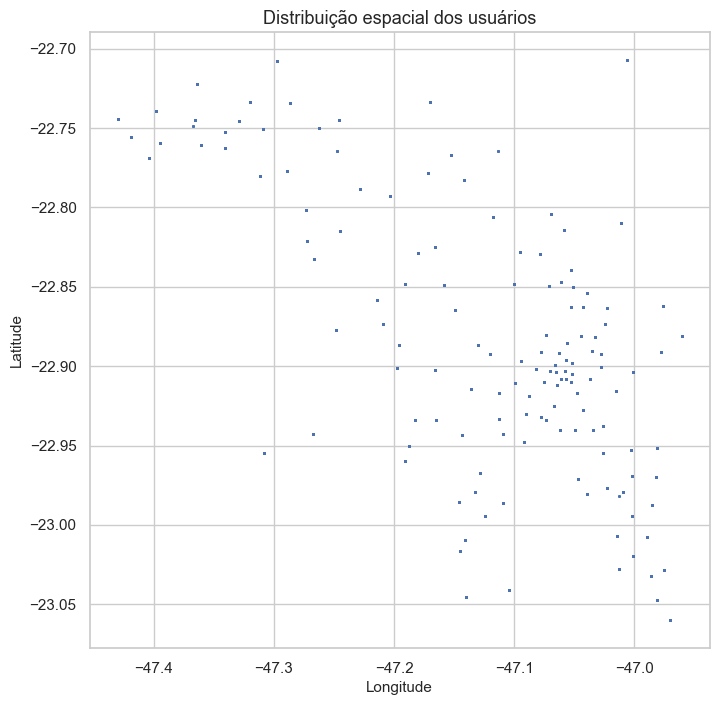

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

plt.scatter(
    users["emissor_lon"],
    users["emissor_lat"],
    s=1,
    alpha=0.3
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Distribuição espacial dos usuários")

plt.show()

## Verificar limites

In [43]:
users[["emissor_lon","emissor_lat"]].describe()

,emissor_lon,emissor_lat
count,22688.000000,22688.000000
mean,-47.138280,-22.887884
std,0.100444,0.080173
min,-47.429790,-23.060090
25%,-47.190860,-22.942970
50%,-47.128840,-22.899430
75%,-47.058070,-22.832170
max,-46.960830,-22.707260


## Distribuição Espacial dos Usuários

In [45]:
nodes_emissor = edges_geo[
    ["id_emisor", "emissor_lon", "emissor_lat"]
].rename(
    columns={
        "id_emisor": "id",
        "emissor_lon": "lon",
        "emissor_lat": "lat"
    }
)

nodes_receptor = edges_geo[
    ["id_receiver", "receptor_lon", "receptor_lat"]
].rename(
    columns={
        "id_receiver": "id",
        "receptor_lon": "lon",
        "receptor_lat": "lat"
    }
)

nodes = pd.concat(
    [nodes_emissor, nodes_receptor]
).drop_duplicates("id")

In [46]:
print(len(nodes))
nodes.head()

25176


,id,lon,lat
1,E251FECC98A8A1A6A669F4A96E5E83FD,-47.09160,-22.94778
2,89DCFE25604A02CB8B80725D4AA896C6,-47.19113,-22.84812
3,1DEF0A07C69528F86FC5F9540511BD10,-47.08188,-22.90203
4,9749A47A3F466E787C1262E04FFDA8A1,-47.19751,-22.90135
5,D4A62AA301336DBC49DA15BE818665A1,-47.24870,-22.87702


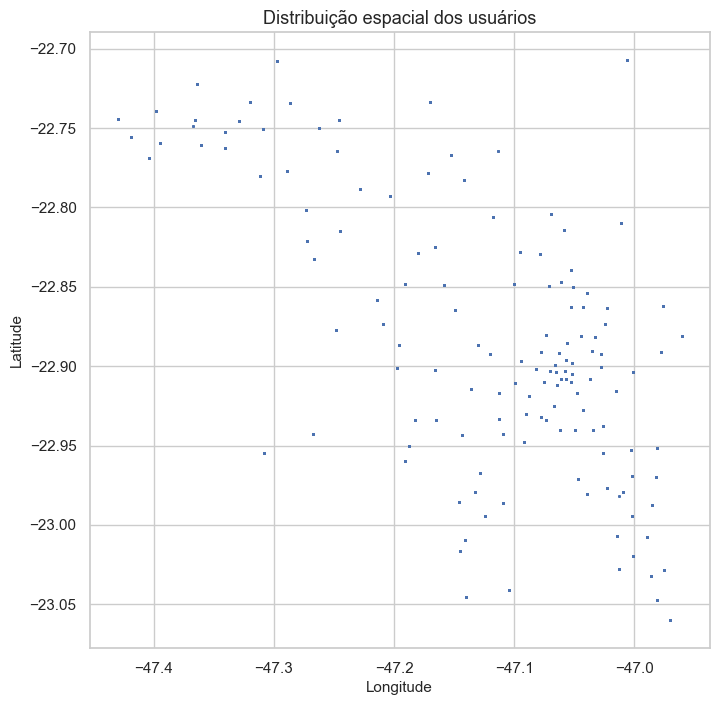

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

plt.scatter(
    nodes["lon"],
    nodes["lat"],
    s=1,
    alpha=0.3
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Distribuição espacial dos usuários")

plt.show()

## Distribuição espacial sobre o mapa de Campinas

In [48]:
import geopandas as gpd

gdf = gpd.GeoDataFrame(
    nodes,
    geometry=gpd.points_from_xy(
        nodes["lon"],
        nodes["lat"]
    ),
    crs="EPSG:4326"
)

In [49]:
gdf = gdf.to_crs(epsg=3857)

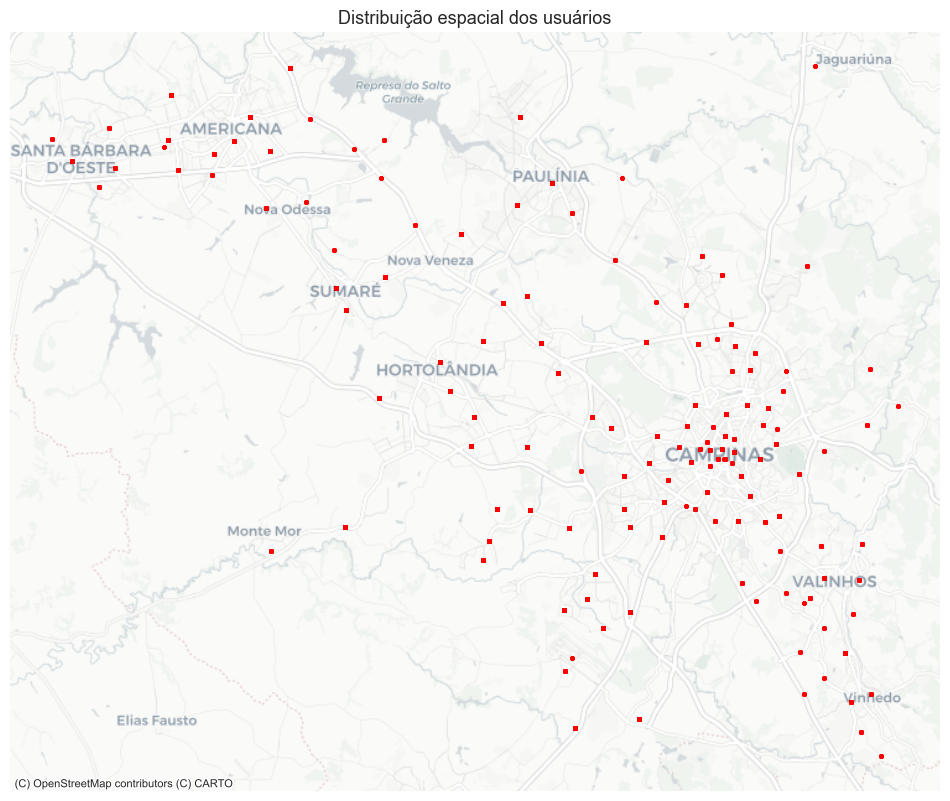

In [55]:
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as ctx

fig, ax = plt.subplots(figsize=(12, 12))

gdf.plot(
    ax=ax,
    markersize=5,      # aumente bastante
    alpha=0.5,
    color="red"
)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron
)

ax.set_axis_off()

plt.title("Distribuição espacial dos usuários")
plt.show()

In [57]:
top_edges = edges_geo[
    edges_geo["q_calls"] >= 10
].copy()

In [58]:
top_edges = (
    edges_geo
    .sort_values("q_calls", ascending=False)
    .head(500)
)

In [59]:
from shapely.geometry import LineString
import geopandas as gpd

linhas = []

for _, row in top_edges.iterrows():

    linha = LineString([
        (row["emissor_lon"], row["emissor_lat"]),
        (row["receptor_lon"], row["receptor_lat"])
    ])

    linhas.append(linha)

gdf_edges = gpd.GeoDataFrame(
    top_edges,
    geometry=linhas,
    crs="EPSG:4326"
)

In [60]:
gdf_edges = gdf_edges.to_crs(epsg=3857)
gdf_nodes = gdf.to_crs(epsg=3857)

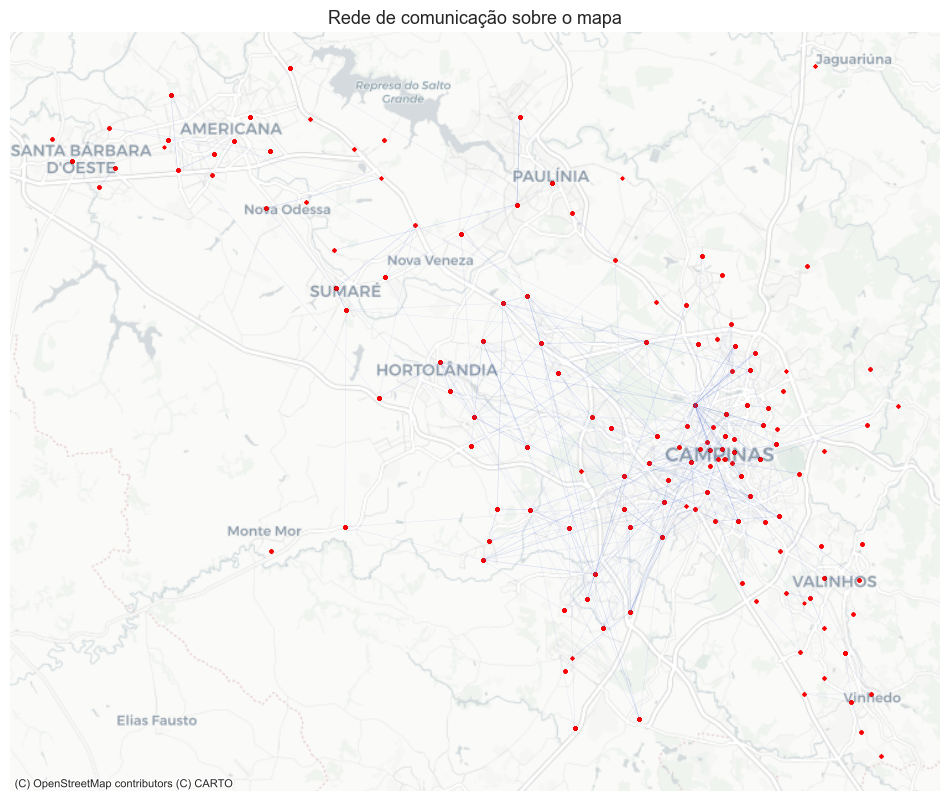

In [61]:
import matplotlib.pyplot as plt
import contextily as ctx

fig, ax = plt.subplots(figsize=(12,12))

# arestas
gdf_edges.plot(
    ax=ax,
    linewidth=0.3,
    alpha=0.15,
    color="royalblue"
)

# nós
gdf_nodes.plot(
    ax=ax,
    markersize=2,
    color="red",
    alpha=0.5
)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron
)

ax.set_axis_off()

plt.title(
    "Rede de comunicação sobre o mapa"
)

plt.show()

## Distribuição das comunidades

In [62]:
community_dict = {}

for i, comm in enumerate(communities):

    for node in comm:

        community_dict[node] = i

In [63]:
nodes.head()

,id,lon,lat
1,E251FECC98A8A1A6A669F4A96E5E83FD,-47.09160,-22.94778
2,89DCFE25604A02CB8B80725D4AA896C6,-47.19113,-22.84812
3,1DEF0A07C69528F86FC5F9540511BD10,-47.08188,-22.90203
4,9749A47A3F466E787C1262E04FFDA8A1,-47.19751,-22.90135
5,D4A62AA301336DBC49DA15BE818665A1,-47.24870,-22.87702


In [65]:
nodes["community"] = (
    nodes["id"]
    .map(community_dict)
)

In [66]:
nodes["community"].value_counts().head()

community
0.0    480
1.0    449
2.0    406
3.0    305
4.0    282
Name: count, dtype: int64

In [68]:
gdf_nodes = gpd.GeoDataFrame(
    nodes,
    geometry=gpd.points_from_xy(
        nodes["lon"],
        nodes["lat"]
    ),
    crs="EPSG:4326"
)

gdf_nodes = gdf_nodes.to_crs(3857)

In [69]:
sizes = [len(c) for c in communities]

top_communities = sorted(
    range(len(sizes)),
    key=lambda x: sizes[x],
    reverse=True
)[:10]

In [70]:
plot_nodes = gdf_nodes[
    gdf_nodes["community"].isin(top_communities)
]

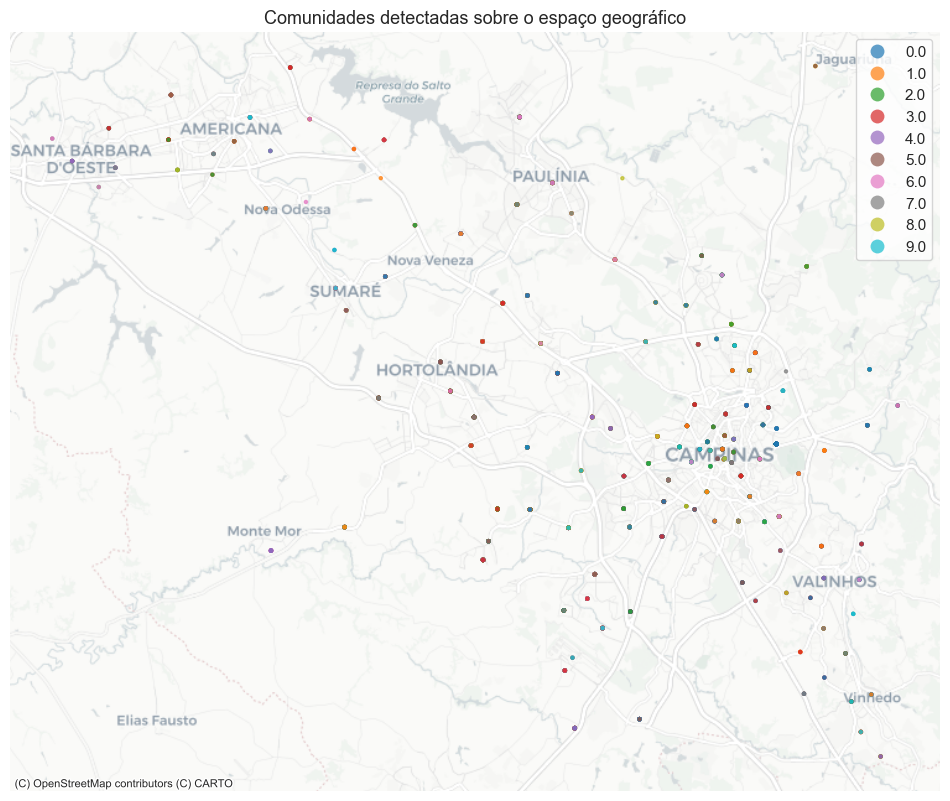

In [71]:
fig, ax = plt.subplots(
    figsize=(12,12)
)

plot_nodes.plot(
    ax=ax,
    column="community",
    categorical=True,
    markersize=5,
    alpha=0.7,
    legend=True
)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron
)

ax.set_axis_off()

plt.title(
    "Comunidades detectadas sobre o espaço geográfico"
)

plt.show()